# Homework 17.3 - Coding

This is the coding portion of the homework assignment for Section 17.3

In [10]:
import numpy as np
from scipy.stats import beta as beta_dist
from matplotlib import pyplot as plt 

Here is the code for Algorithm 17.1 (Thompson Sampling) that you need to use on your homework.

In [11]:
### ------------ Book Code for Thompson Sampling (Algorithm 17.1) ------------ ### 
def thompson(theta, N):
    """Thomson sample to choose the arm, then simulate a pull, then update. 
    
    Repeat N times.
    
    Parameters:
        theta ((n,) ndarray) : Array of true probabilities for success
            on each of the n arms 
        N (int): Total number of pulls to make. 
    
    Returns:
        ndarray(float): Percentage of successes up to each time step
    """
    # -------------- Initialize --------------
    n = len(theta)      # Number of arms on the Bernoulli bandit 
    a = np.ones(n)      # Initialize `a` hyperparameters 
                        # (number of successes on each arm)
    b = np.ones(n)      # Initialize `b` hyperparameters
                        # (number of failures on each arm)
    X = np.random.uniform(low=0, high=1, size=N)    # Used for drawing from Bernoulli(theta_i) 
                                                    # at each stage 
                                                    # (success at kth stage if X[k] <= theta_i)
    traj = np.zeros(N)      # Trajectory (traj[k] is number of successes up to kth step)
    
    # -------------- Run algorithm --------------
    for k in range(N):
        draw = beta_dist.rvs(a,b)        # Thompson sample for all arms 
        index = np.argmax(draw) # Identify arm to pull 

        # Simulate pull from Bernoulli distribution on the chosen arm (index)
        if X[k] <= theta[index]: 
            a[index] += 1           # Had success on the chosen arm (index)
            traj[k] = traj[k-1]+ 1  # Update trajectory to include this success 
        else:
            b[index] += 1           # Had failure on chosen arm (index)
            traj[k] = traj[k-1]     # Update trajetory to include this failure 
        
    # Normalize trajectory to percentage of success, and return 
    return traj/np.arange(1,N+1)

## Problem 17.13 

Write a program that performs A/B testing. 

1. Have each arm tested $m$ times to estimate each $(\theta_1, \ldots, \theta_n)$ with the MLE estimator.
2. Then choose the largest $\theta_i$ and use the remaining $N-nm$ pulls (where $N$ is the total number of pulls) to try and maximize the average payoff by only pulling that arm.

**HINT:** The MLE estimate for the parameter $\theta$ of success in a Bernoulli distribution is discussed on p.248-249 in the textbook in Example 6.1.10 (they use $p$ to be the parameter instead of $\theta$).

In [12]:
def ab(
    theta:list[float],
    N:int,
    m:int
) -> np.ndarray:
    """Perform AB testing on an n-arm Bernoulli bandit process.
    
    Run a total of N pulls in two phases:
    
    1) In the exploration phase, for each of the n arms, pull the arm m times
        and estimate the probability of success using the MLE estimator.
    2) In the exploitation phase, choose the arm with the largest estimated 
        probability of success, and use the remaining N-nm pulls to try and 
        maximize the average payoff.

    Parameters:
        theta ((n,) list or array): The true probabilities of success
            for each arm of the Bernoulli bandit
        N (int): The total number of pulls to make (should be at least n*m)
        m (int): The number of pulls to make on each arm during the 
            exploration phase
    
    Returns: 
        traj ((N,) ndarrray): The percentage of successes over the 
            total number of pulls up to each point; that is, 
            traj[k] = (num successes up to point k in time)/(k+1)
    """
    total_is_success_list = []

    # EXPLORATION
    
    # flip each arm m times
    # I think that each theta represents an arm.
    ps = []
    for arm in theta:
        is_success_list = np.random.uniform(0, 1, m) <= np.ones(m) * arm
        p = sum(is_success_list) / m # this is the mle estimated probability of success
        ps.append(p)

        total_is_success_list.extend(is_success_list)

    
    # EXPLOITATION
    best_arm = np.argmax(ps)
    pulls_leftover = N - len(theta) * m
    is_success_list = np.random.uniform(0, 1, pulls_leftover) <= np.ones(pulls_leftover) * theta[best_arm]

    total_is_success_list.extend(is_success_list)

    total_is_success_array = np.array(total_is_success_list, dtype=int) # convert to ints from booleans
    cumulative_successes = np.cumsum(total_is_success_array) # parse the total successes into a cumulative list

    b_plus_one = np.array(range(1, N + 1), dtype=float)

    return cumulative_successes / b_plus_one  # divide by b_k + 1 to get percentages

Now, run the following code cell to compare the average payout using A/B Testing with the average payout from Thompson sampling in Algorithm 17.1.

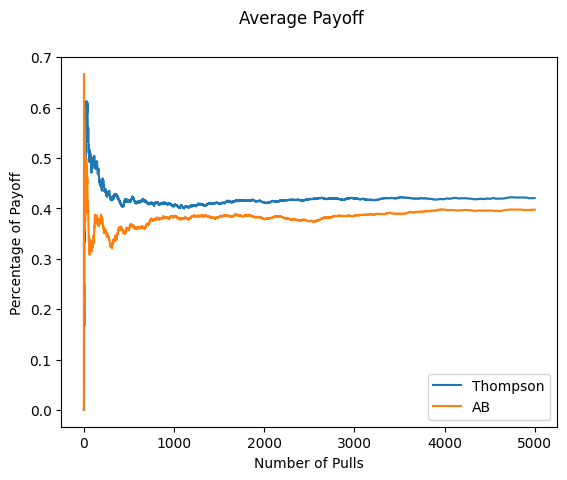

In [13]:
### ----------------------- DO NOT EDIT THIS CELL ------------------------- ### 
### ----- Just run the cell once you've finished writing the function ----- ###

theta = [0.30, 0.45, 0.23, 0.4]     # True probabilities of a 4-armed bandit
N = 5000                            # Total number of pulls 
m = 100                             # Number of exploration pulls per arm 

# Run the two different algorithms
traj_thompson = thompson(theta, N)
traj_ab = ab(theta, N, m)

# Plot results 
plt.plot(range(1,N+1), traj_thompson, label='Thompson')
plt.plot(range(1,N+1), traj_ab, label='AB')
plt.suptitle("Average Payoff")
plt.xlabel("Number of Pulls")
plt.ylabel("Percentage of Payoff")
plt.legend(loc='lower right')
plt.show()


## Problem 17.14 

As an alternative to A/B testing, try randomly choosing arms (with replacement) $m$ times and give MLE estimates for each $(\theta_1, \ldots, \theta_n)$. Then choose the largest $\theta_i$ and use the remaining $N-m$ pulls to try and maximize the average payoff. Compare the average payoff with A/B testing and Thompson Sampling.

In [ ]:
def random_arm_exploration(
    theta:list[float],
    N:int,
    m:int
) -> np.ndarray:
    """Perform testing on an n-arm Bernoulli bandit process.
    
    Run a total of N pulls in two phases:
    
    1) In the exploration phase, for m pulls, randomly choose an arm, and use 
        that to find an MLE estimate for the probability of success on each arm
    2) In the exploitation phase, choose the arm with the largest estimated 
        probability of success, and use the remaining N-m pulls to try and 
        maximize the average payoff.

    Parameters:
        theta ((n,) list or array): The true probabilities of success
            for each arm of the Bernoulli bandit
        N (int): The total number of pulls to make (should be at least n*m)
        m (int): The number of pulls to make on each arm during the 
            exploration phase
    
    Returns: 
        traj ((N,) ndarrray): The percentage of successes over the 
            total number of pulls up to each point; that is, 
            traj[k] = (num successes up to point k in time)/(k+1)
    """

    total_is_success_list = []

    # EXPLORATION
    n = len(theta)

    # randomly distribute the m pulls between the n arms:
    assignments = np.random.randint(0, m, size=m)
    counts = np.bincount(assignments, minlength=n)

    
    # flip each arm m times
    # I think that each theta represents an arm.
    ps = []
    for i, arm in enumerate(theta):
        num_pulls = counts[i]
        is_success_list = np.random.uniform(0, 1, num_pulls) <= np.ones(num_pulls) * arm
        p = sum(is_success_list) / num_pulls # this is the mle estimated probability of success
        ps.append(p)

        total_is_success_list.extend(is_success_list)

    
    # EXPLOITATION
    best_arm = np.argmax(ps)
    pulls_leftover = N - m
    is_success_list = np.random.uniform(0, 1, pulls_leftover) <= np.ones(pulls_leftover) * theta[best_arm]

    total_is_success_list.extend(is_success_list)

    total_is_success_array = np.array(total_is_success_list, dtype=int) # convert to ints from booleans
    cumulative_successes = np.cumsum(total_is_success_array) # parse the total successes into a cumulative list

    b_plus_one = np.array(range(1, N + 1), dtype=float)

    return cumulative_successes / b_plus_one  # divide by b_k + 1 to get percentages
    return np.zeros(N)

Now, run the following code cell to compare the average payout using this random sampling algorithm to the average payout using A/B Testing and Thompson sampling. 

In [27]:
### ----------------------- DO NOT EDIT THIS CELL ------------------------- ### 
### ----- Just run the cell once you've finished writing the function ----- ###

theta = [0.30, 0.45, 0.23, 0.4]     # True probabilities of a 4-armed bandit
N = 5000                            # Total number of pulls 
m_ab = 200                          # Number of exploration pulls per arm 
m_random = 4 * m_ab 

# Run the two different algorithms
traj_thompson = thompson(theta, N)
traj_ab = ab(theta, N, m_ab)
traj_random_arm = random_arm_exploration(theta, N, m_random)

# Plot results 
plt.plot(range(1,N+1), traj_thompson, label='Thompson')
plt.plot(range(1,N+1), traj_ab, label='AB')
plt.plot(range(1,N+1), traj_random_arm, label='Random Arm')
plt.suptitle(f"Average Payoff Over Time\nThompson: {np.mean(traj_thompson):0.2f}    AB: {np.mean(traj_ab):0.2f}   Random Arm: {np.mean(traj_random_arm):0.2f}")
plt.xlabel("Number of Pulls")
plt.ylabel("Percentage of Payoff")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/var/folders/cr/w_svlkb51rj4kw8tbht3hyhc0000gn/T/ipykernel_82831/1757972358.py:44: RuntimeWarning: invalid value encountered in scalar divide
  p = sum(is_success_list) / num_pulls # this is the mle estimated probability of success


ValueError: operands could not be broadcast together with shapes (4205,) (5000,) 

## Problem 17.15 

Instead of evaluating algorithms based on an average (undiscounted) payout over time, reapply A/B testing and Thompson sampling but asses the quality with the *discounted* utility function $\sum_{i=1}^{N} \beta^i u_i$, where $u_i$ is the payoff. By doing multiple runs, compute the expected utility and use that as the basis of comparison for deciding whether Thompson sampling is better than A/B testing.

**Hint:** Copy code from your functions from above (most of it will be the same), but instead of recording the percentages of things correct in the output array, record the total utility gained up to that point in time. To do this, at each step $k$, assume that $u_i = 1$ if you are successful and $u_i=0$ if you fail, and thus, record the $k$ th element as $\sum_{i=1}^{k}\beta^i u_i$.

In [24]:
### ------------ Book Code for Thompson Sampling (Algorithm 17.1) ------------ ### 
def discounted_thompson(
    theta:list[float],
    N:int,
    beta:float
) -> np.ndarray:
    """Thomson sample to choose the arm, then simulate a pull, then update. 
    
    Repeat N times.
    
    Parameters:
        theta ((n,) ndarray) : Array of true probabilities for success
            on each of the n arms 
        N (int): Total number of pulls to make. 
        beta (float): Discount factor
    
    Returns:
        total_utility ((N,) ndarrray): The total utility at each point 
            in time (taking discounting with beta into account)
    """
    # -------------- Initialize --------------
    n = len(theta)      # Number of arms on the Bernoulli bandit 
    a = np.ones(n)      # Initialize `a` hyperparameters 
                        # (number of successes on each arm)
    b = np.ones(n)      # Initialize `b` hyperparameters
                        # (number of failures on each arm)
    X = np.random.uniform(low=0, high=1, size=N)    # Used for drawing from Bernoulli(theta_i) 
                                                    # at each stage 
                                                    # (success at kth stage if X[k] <= theta_i)

    utility = np.zeros(N)
    
    # -------------- Run algorithm --------------
    for k in range(N):
        draw = beta_dist.rvs(a,b)        # Thompson sample for all arms 
        index = np.argmax(draw) # Identify arm to pull 

        # Simulate pull from Bernoulli distribution on the chosen arm (index)
        if X[k] <= theta[index]: 
            a[index] += 1           # Had success on the chosen arm (index)
            utility[k] = beta ** (k + 1)  # Update dis
        else:
            b[index] += 1           # Had failure on chosen arm (index)
            # leave untility as zero

    # return the sumulative sum of utility to get the total utility at each point
    return np.cumsum(utility)



def discounted_ab(
    theta:list[float],
    N:int,
    m:int, 
    beta:float
) -> np.ndarray:
    """Perform AB testing on an n-arm Bernoulli bandit process with 
    a discount factor for the utility.
    
    Run a total of N pulls in two phases:
    
    1) In the exploration phase, for each of the n arms, pull the arm m times
        and estimate the probability of success using the MLE estimator.
    2) In the exploitation phase, choose the arm with the largest estimated 
        probability of success, and use the remaining N-nm pulls to try and 
        maximize the average payoff.

    Parameters:
        theta ((n,) list or array): The true probabilities of success
            for each arm of the Bernoulli bandit
        N (int): The total number of pulls to make (should be at least n*m)
        m (int): The number of pulls to make on each arm during the 
            exploration phase
        beta (float): The discount factor
    
    Returns: 
        total_utility ((N,) ndarrray): The total utility at each point 
            in time (taking discounting with beta into account)
    """
    total_is_success_list = []

    # EXPLORATION
    
    # flip each arm m times
    # each theta represents an arm.
    ps = []
    for arm in theta:
        is_success_list = np.random.uniform(0, 1, m) <= np.ones(m) * arm
        p = sum(is_success_list) / m # this is the mle estimated probability of success
        ps.append(p)

        total_is_success_list.extend(is_success_list)


    # EXPLOITATION
    best_arm = np.argmax(ps)
    pulls_leftover = N - len(theta) * m
    is_success_list = np.random.uniform(0, 1, pulls_leftover) <= np.ones(pulls_leftover) * theta[best_arm]

    total_is_success_list.extend(is_success_list)

    total_is_success_array = np.array(total_is_success_list, dtype=int) # convert to ints from booleans
    discounts = beta ** np.arange(1, N + 1) # encode beta^k as an array
    utility = total_is_success_array * discounts # element-wise multiply the utility by its discount

    return np.cumsum(utility)  # return cumulative utility

Finally, run the following code cell to compare the total (discounted) utility gained over time using Thompson sampling versus A/B Testing on a 4-armed bandit with the following true probabilities of success:
$$\begin{bmatrix} \theta_1 & \theta_2 & \theta_3 & \theta_4 \end{bmatrix} = \begin{bmatrix} 0.3 & 0.45 & 0.23 & 0.4 \end{bmatrix}$$

for $N=5000$ pulls with a discount factor of $\beta = 0.95$, using $m=200$ exploration pulls per arm for the A/B Testing.

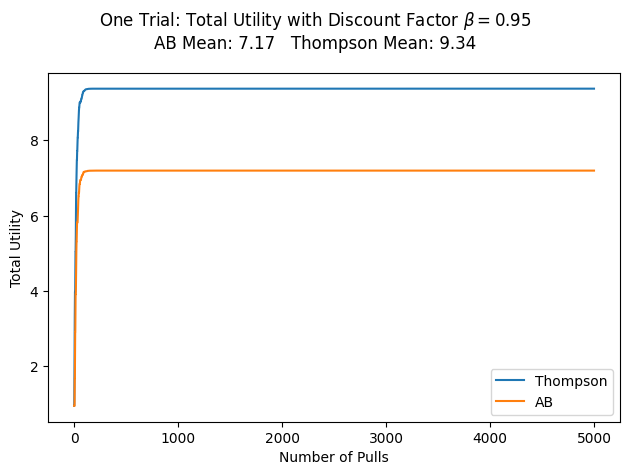


Getting estimate for expected total utility of these algorithms over 10 iterations....
Expected Utility of Thompson Sampling: 7.28
Expected Utility of A/B Testing: 5.90


In [25]:
### ----------------------- DO NOT EDIT THIS CELL ------------------------- ### 
### ----- Just run the cell once you've finished writing the functions above ----- ###

num_trials = 10                     # Number of trials to run
theta = [0.30, 0.45, 0.23, 0.4]     # True probabilities of a 4-armed bandit
N = 5000                            # Total number of pulls 
m = 200                             # Number of exploration pulls per arm 
beta = 0.95                         # Discount factor 

thompson_utility = discounted_thompson(theta, N, beta)
ab_utility = discounted_ab(theta, N, m, beta)
plt.plot(range(1,N+1), thompson_utility, label='Thompson')
plt.plot(range(1,N+1), ab_utility, label='AB')
plt.suptitle(f"One Trial: Total Utility with Discount Factor $\\beta = {beta}$\nAB Mean: {np.mean(ab_utility):.2f}   Thompson Mean: {np.mean(thompson_utility):.2f}")
plt.xlabel("Number of Pulls")
plt.ylabel("Total Utility")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Now, run 10 trials to estimate expected utility ---------
# Run trials to get estimate for expected utility
print("\nGetting estimate for expected total utility of these algorithms over 10 iterations....")
ab_utilities = []
thompson_utilities = []
for _ in range(num_trials):
    thompson_utility = discounted_thompson(theta, N, beta)[-1]
    ab_utility = discounted_ab(theta, N, m, beta)[-1]
    thompson_utilities.append(thompson_utility)
    ab_utilities.append(ab_utility)

# Display results 
print(f"Expected Utility of Thompson Sampling: {np.mean(thompson_utilities):.2f}")
print(f"Expected Utility of A/B Testing: {np.mean(ab_utilities):.2f}")

---

IMPORTANT: Please "Restart and Run All" and ensure there are no errors. Then, submit this .ipynb file to Gradescope.